--- Spending Prediction Model (Linear Regression) ---
RMSE (Root Mean Squared Error): nan
MAE (Mean Absolute Error):      nan
R² (R-Squared):                 nan


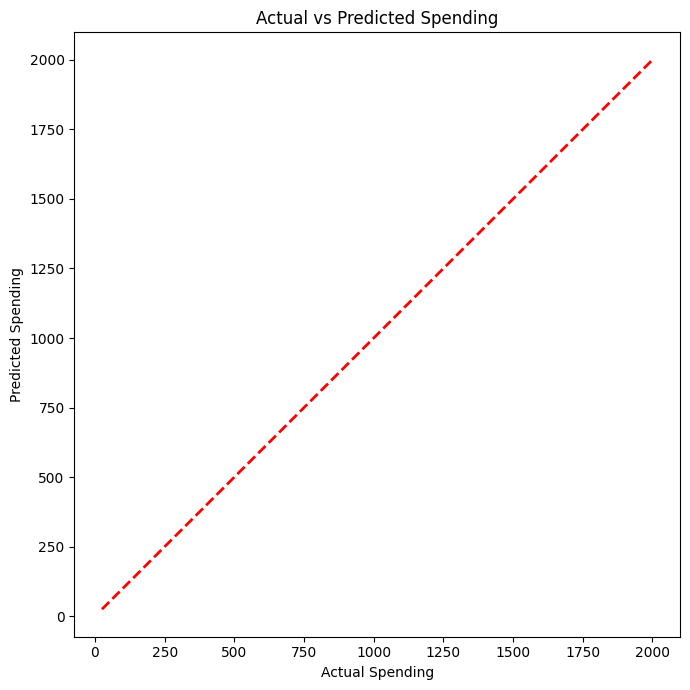

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# 1. Load your preprocessed data 
X_train = pd.read_pickle("../data/processed/spend_X_train.pkl")
y_train = pd.read_pickle("../data/processed/spend_y_train.pkl")
X_test  = pd.read_pickle("../data/processed/spend_X_test.pkl")
y_test  = pd.read_pickle("../data/processed/spend_y_test.pkl")

# 2. Drop non-numeric columns so Numpy doesn't crash
cols_to_drop = ["Transaction ID", "Date", "Customer ID"]
X_train_clean = X_train.drop(columns=cols_to_drop)
X_test_clean = X_test.drop(columns=cols_to_drop)

# 3. Add an intercept column (column of 1s) and convert to float
X_train_np = np.c_[np.ones(X_train_clean.shape[0]), X_train_clean.to_numpy(dtype=float)]
X_test_np = np.c_[np.ones(X_test_clean.shape[0]), X_test_clean.to_numpy(dtype=float)]
y_train_np = y_train.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

# 4. Train Linear Regression (Pure Numpy)
weights = np.linalg.inv(X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

# 5. Make Predictions
y_pred = X_test_np @ weights

# 6. Calculate Regression Metrics (Prediction Error Focus)
rmse = np.sqrt(np.mean((y_test_np - y_pred)**2))
mae = np.mean(np.abs(y_test_np - y_pred))

# Calculate R-Squared (R²)
ss_res = np.sum((y_test_np - y_pred)**2)
ss_tot = np.sum((y_test_np - np.mean(y_test_np))**2)
r2 = 1 - (ss_res / ss_tot)

print("--- Spending Prediction Model (Linear Regression) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error):      {mae:.2f}")
print(f"R² (R-Squared):                 {r2:.4f}")

# 7. Plot Predicted vs Actual
plt.figure(figsize=(7,7))
plt.scatter(y_test_np, y_pred, alpha=0.5, color='#4C72B0')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
plt.xlabel("Actual Spending")
plt.ylabel("Predicted Spending")
plt.title("Actual vs Predicted Spending")
plt.tight_layout()
plt.show()

# 8. Save model weights into the main models folder
with open("../models/spend_model_weights.pkl", "wb") as f:
    pickle.dump(weights, f)

